### Ejemplo de coaliación en el juego de votaciones

In [12]:
import os
import sys
import math
import pandas as pd
import shap


file_root_shapley = os.path.join(
    "..", "..", "data", "exact", "shapley_value_of_parliament.csv"
)
file_root_grabisch = os.path.join(
    "..", "..", "data", "exact", "grabisch_of_parliament.csv"
)
original = pd.read_csv(os.path.join(
    "..", "..", "data", "input", "parliament.csv"
), sep=";").set_index(
    "label",
    verify_integrity=True
)

shapley_only = pd.read_csv(
    file_root_shapley,
    sep=";",
    header=None,
    names=["value"]
)
shapley_only = shapley_only.set_index(
    original.index.values,
    verify_integrity=True
)
psi_1 = original.join(shapley_only)

r_1 = pd.read_csv(
    file_root_grabisch,
    sep=";",
    header=0
).set_index(
    original.index.values,
    verify_integrity=True
)
r_1.columns = original.index.values

In [13]:
display(r_1)

,A,B,C,D,E,F,G,H,I,J
A,0.000000,0.014286,-0.004762,-0.002381,0.004762,-0.002381,-0.002381,-0.007143,0.000000,0.000000
B,0.014286,0.000000,-0.002381,0.000000,-0.009524,0.000000,0.000000,-0.002381,0.000000,0.000000
C,-0.004762,-0.002381,0.000000,0.014286,0.004762,-0.002381,-0.002381,-0.007143,0.000000,0.000000
D,-0.002381,0.000000,0.014286,0.000000,-0.009524,0.000000,0.000000,-0.002381,0.000000,0.000000
E,0.004762,-0.009524,0.004762,-0.009524,0.000000,0.007143,0.007143,-0.004762,0.000000,0.000000
F,-0.002381,0.000000,-0.002381,0.000000,0.007143,0.000000,0.000000,-0.002381,0.000000,0.000000
G,-0.002381,0.000000,-0.002381,0.000000,0.007143,0.000000,0.000000,-0.002381,0.000000,0.000000
H,-0.007143,-0.002381,-0.007143,-0.002381,-0.004762,-0.002381,-0.002381,0.000000,0.014286,0.014286
I,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014286,0.000000,-0.014286
J,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014286,-0.014286,0.000000


### Truncated characteristic values

In [14]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r


n = 4
psi_1_truncated = psi_1.copy()
psi_1_truncated["value"] = psi_1_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_1_truncated = r_1.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

psi_2 = normalize_psi(psi_1)
psi_2_truncated = psi_2.copy()
psi_2_truncated["value"] = psi_2_truncated["value"].astype(float).apply(lambda number: math.floor(number * 10 ** n) / 10 ** n)

r_2 = normalize_r(r_1)
r_2_truncated = r_2.astype(float).apply(lambda row: row.apply(lambda number: math.floor(number * 10 ** n) / 10 ** n))

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


#### Benefit Allocation Results

The Shapley values for this game are calculated in the file ./data/exact/shapley_value_of_bankruptcy.csv. In the table below we represent these values:

In [15]:
psi_1_truncated

,player,votes,value
label,,,
A,Labour Party,29,0.3226
B,Conservative Party,26,0.2615
C,Centre Party,16,0.1559
D,Progress Party,13,0.0948
E,Socialist Left Party,6,0.0753
F,Liberal Party,3,0.0281
G,Red Party,3,0.0281
H,Green Party,2,0.0206
I,Christian Democratic Party,1,0.0063


In [16]:
psi_2_truncated

,player,votes,value
label,,,
A,Labour Party,29,1.0000
B,Conservative Party,26,0.8105
C,Centre Party,16,0.4833
D,Progress Party,13,0.2939
E,Socialist Left Party,6,0.2337
F,Liberal Party,3,0.0873
G,Red Party,3,0.0873
H,Green Party,2,0.0639
I,Christian Democratic Party,1,0.0196


The Grabisch values of all the pairs in the game can be found in the file ./data/exact/grabisch_of_bankruptcy.csv. In the following table, we represent these values.

In [17]:
r_1_truncated

,A,B,C,D,E,F,G,H,I,J
A,0.0000,0.0142,-0.0048,-0.0024,0.0047,-0.0024,-0.0024,-0.0072,0.0000,0.0000
B,0.0142,0.0000,-0.0024,0.0000,-0.0096,0.0000,0.0000,-0.0024,0.0000,0.0000
C,-0.0048,-0.0024,0.0000,0.0142,0.0047,-0.0024,-0.0024,-0.0072,0.0000,0.0000
D,-0.0024,0.0000,0.0142,0.0000,-0.0096,0.0000,0.0000,-0.0024,0.0000,0.0000
E,0.0047,-0.0096,0.0047,-0.0096,0.0000,0.0071,0.0071,-0.0048,0.0000,0.0000
F,-0.0024,0.0000,-0.0024,0.0000,0.0071,0.0000,0.0000,-0.0024,0.0000,0.0000
G,-0.0024,0.0000,-0.0024,0.0000,0.0071,0.0000,0.0000,-0.0024,0.0000,0.0000
H,-0.0072,-0.0024,-0.0072,-0.0024,-0.0048,-0.0024,-0.0024,0.0000,0.0142,0.0142
I,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0142,0.0000,-0.0143
J,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0142,-0.0143,0.0000


In [18]:
r_2_truncated

,A,B,C,D,E,F,G,H,I,J
A,0.0000,1.0000,-0.3334,-0.1667,0.3333,-0.1667,-0.1667,-0.5000,0.0,0.0
B,1.0000,0.0000,-0.1667,0.0000,-0.6667,0.0000,0.0000,-0.1667,0.0,0.0
C,-0.3334,-0.1667,0.0000,1.0000,0.3333,-0.1667,-0.1667,-0.5000,0.0,0.0
D,-0.1667,0.0000,1.0000,0.0000,-0.6667,0.0000,0.0000,-0.1667,0.0,0.0
E,0.3333,-0.6667,0.3333,-0.6667,0.0000,0.5000,0.5000,-0.3334,0.0,0.0
F,-0.1667,0.0000,-0.1667,0.0000,0.5000,0.0000,0.0000,-0.1667,0.0,0.0
G,-0.1667,0.0000,-0.1667,0.0000,0.5000,0.0000,0.0000,-0.1667,0.0,0.0
H,-0.5000,-0.1667,-0.5000,-0.1667,-0.3334,-0.1667,-0.1667,0.0000,1.0,1.0
I,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0,-1.0
J,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,-1.0,0.0


### Absolute value $\|I\|$

In [19]:
r_1_abs = r_1.astype(float).apply(lambda row: row.apply(lambda number: abs(number)))
r_1_abs

,A,B,C,D,E,F,G,H,I,J
A,0.000000,0.014286,0.004762,0.002381,0.004762,0.002381,0.002381,0.007143,0.000000,0.000000
B,0.014286,0.000000,0.002381,0.000000,0.009524,0.000000,0.000000,0.002381,0.000000,0.000000
C,0.004762,0.002381,0.000000,0.014286,0.004762,0.002381,0.002381,0.007143,0.000000,0.000000
D,0.002381,0.000000,0.014286,0.000000,0.009524,0.000000,0.000000,0.002381,0.000000,0.000000
E,0.004762,0.009524,0.004762,0.009524,0.000000,0.007143,0.007143,0.004762,0.000000,0.000000
F,0.002381,0.000000,0.002381,0.000000,0.007143,0.000000,0.000000,0.002381,0.000000,0.000000
G,0.002381,0.000000,0.002381,0.000000,0.007143,0.000000,0.000000,0.002381,0.000000,0.000000
H,0.007143,0.002381,0.007143,0.002381,0.004762,0.002381,0.002381,0.000000,0.014286,0.014286
I,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014286,0.000000,0.014286
J,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014286,0.014286,0.000000


In [20]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3] 

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 0, \beta^{-} = 0}^{2}$

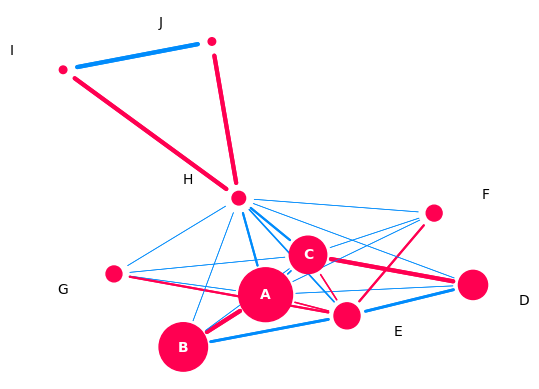

In [23]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=0,
    negative_beta=0,
    symmetric=True,
    layout="spring",
    label_margin=0.08,
    positive_color=positive_color,
    negative_color=negative_color,
)

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 1; \beta^{-} = 0}^{2}$

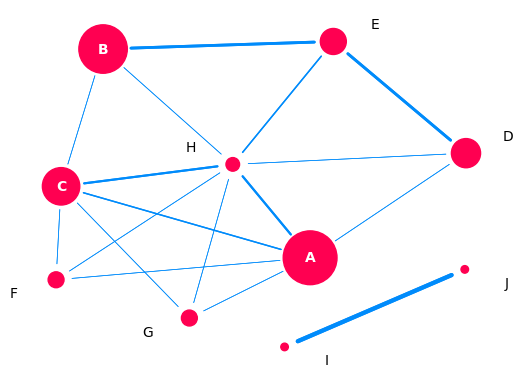

In [24]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0,
    negative_alpha=0,
    positive_beta=1,
    negative_beta=0,
    symmetric=True,
    layout="kamada_kawai",
    label_margin=0.08,
    positive_color=positive_color,
    negative_color=negative_color,
)

####  $\Psi_{\alpha^{+} = 0, \alpha^{-} = 0}^{2}; R_{\beta^{+} = 1; \beta^{-} = 0.1}^{2}$

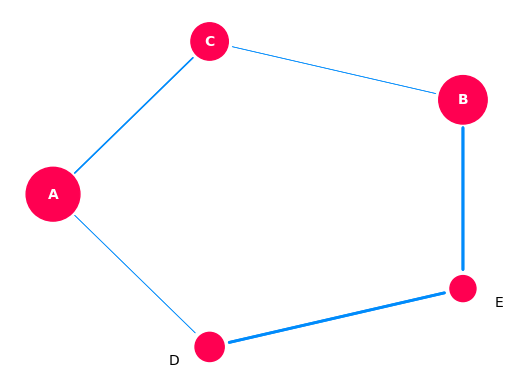

In [25]:
import os
import sys

from cgt_perezsechi.visualization.graph import draw

draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=0.1,
    negative_alpha=0,
    positive_beta=1,
    negative_beta=0,
    symmetric=True,
    layout="kamada_kawai",
    label_margin=0.08,
    positive_color=positive_color,
    negative_color=negative_color,
)